# Notebook 1: Compilation & Static QASM Analysis
**Paper 5 – Cross-Framework Quantum Algorithm Benchmarking**

**Purpose**: Run the full compilation pipeline (all algorithms × 3 frameworks → OpenQASM 3.0)
and perform structural analysis on the generated QASM files.

**Outputs**:
- `benchmarks/qasm_outputs/*.qasm` — compiled QASM files
- `benchmarks/metrics/compilation_times.csv`
- `benchmarks/metrics/structural_metrics.csv`

**Pipeline step**: Step 1 of 5

In [1]:
# Setup — run from QCanvas project root
import os, sys
QCANVAS_ROOT = os.path.abspath('../..')
if QCANVAS_ROOT not in sys.path:
    sys.path.insert(0, QCANVAS_ROOT)
print('QCanvas root:', QCANVAS_ROOT)

QCanvas root: c:\Study Material\FYP\QCanvas-Project\QCanvas


In [2]:
# ── Phase 1: Compile all algorithms ─────────────────────────────────────────
import sys
sys.path.insert(0, '../../')
from benchmarks.scripts.compile_all import run_all_compilations, ALGORITHM_REGISTRY

print(f'Algorithm registry: {len(ALGORITHM_REGISTRY)} algorithms')
total_combos = sum(len(e["qubits"]) * 3 for e in ALGORITHM_REGISTRY)
print(f'Total (algo × qubits × framework) combinations: {total_combos}')
print('\nStarting compilation...')

df_times = run_all_compilations(n_repeats=10, verbose=True)
print(f'\nCompilation complete. {df_times["success"].sum()}/{len(df_times)} succeeded.')

Algorithm registry: 12 algorithms
Total (algo × qubits × framework) combinations: 135

Starting compilation...
  Compiling: [1/135] bell_state (2q) — qiskit … ✓  0.56 ± 0.14 ms
  Compiling: [2/135] bell_state (2q) — cirq … ✓  0.36 ± 0.05 ms
  Compiling: [3/135] bell_state (2q) — pennylane … ✓  1.13 ± 0.21 ms
  Compiling: [4/135] ghz_state (3q) — qiskit … ✓  0.54 ± 0.05 ms
  Compiling: [5/135] ghz_state (3q) — cirq … ✓  0.43 ± 0.04 ms
  Compiling: [6/135] ghz_state (3q) — pennylane … ✓  1.13 ± 0.06 ms
  Compiling: [7/135] ghz_state (4q) — qiskit … ✓  0.52 ± 0.03 ms
  Compiling: [8/135] ghz_state (4q) — cirq … ✓  0.42 ± 0.04 ms
  Compiling: [9/135] ghz_state (4q) — pennylane … ✓  1.17 ± 0.31 ms
  Compiling: [10/135] ghz_state (5q) — qiskit … ✓  0.54 ± 0.04 ms
  Compiling: [11/135] ghz_state (5q) — cirq … ✓  0.41 ± 0.03 ms
  Compiling: [12/135] ghz_state (5q) — pennylane … ✓  1.16 ± 0.15 ms
  Compiling: [13/135] ghz_state (6q) — qiskit … ✓  0.52 ± 0.02 ms
  Compiling: [14/135] ghz_state (

In [3]:
# ── Compilation timing summary ───────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from benchmarks.scripts.figure_styles import apply_paper_style, FRAMEWORK_COLORS, FRAMEWORK_LABELS

df_times = pd.read_csv('../metrics/compilation_times.csv')
success = df_times[df_times['success']]

print('Mean compilation time per framework (ms):')
print(success.groupby('framework')['mean_compile_ms'].agg(['mean','std']).round(3))

c:\Study Material\FYP\QCanvas-Project\QCanvas\benchmarks\notebooks\../..\benchmarks\scripts\figure_styles.py:143: SyntaxWarning: invalid escape sequence '\i'
  """


Mean compilation time per framework (ms):
            mean    std
framework              
cirq       0.853  0.436
pennylane  1.379  0.228
qiskit     0.914  0.360


In [4]:
# ── Phase 2: Static QASM analysis ───────────────────────────────────────────
from benchmarks.scripts.analyze_qasm import run_static_analysis

df_struct = run_static_analysis('../qasm_outputs')
df_struct.to_csv('../metrics/structural_metrics.csv', index=False)
print(f'Structural metrics: {len(df_struct)} rows')
df_struct.head()

[analyze_qasm] Found 135 QASM files in ../qasm_outputs/
  ✓  bell_state_2q_cirq.qasm: 5 gates, depth=3, 2Q ratio=20.0%
  ✓  bell_state_2q_pennylane.qasm: 3 gates, depth=2, 2Q ratio=33.3%
  ✓  bell_state_2q_qiskit.qasm: 4 gates, depth=2, 2Q ratio=25.0%
  ✓  bernstein_vazirani_3q_cirq.qasm: 13 gates, depth=4, 2Q ratio=15.4%
  ✓  bernstein_vazirani_3q_pennylane.qasm: 7 gates, depth=0, 2Q ratio=14.3%
  ✓  bernstein_vazirani_3q_qiskit.qasm: 7 gates, depth=2, 2Q ratio=14.3%
  ✓  bernstein_vazirani_4q_cirq.qasm: 13 gates, depth=6, 2Q ratio=15.4%
  ✓  bernstein_vazirani_4q_pennylane.qasm: 7 gates, depth=0, 2Q ratio=14.3%
  ✓  bernstein_vazirani_4q_qiskit.qasm: 7 gates, depth=2, 2Q ratio=14.3%
  ✓  bernstein_vazirani_5q_cirq.qasm: 13 gates, depth=6, 2Q ratio=15.4%
  ✓  bernstein_vazirani_5q_pennylane.qasm: 7 gates, depth=0, 2Q ratio=14.3%
  ✓  bernstein_vazirani_5q_qiskit.qasm: 7 gates, depth=2, 2Q ratio=14.3%
  ✓  bernstein_vazirani_6q_cirq.qasm: 13 gates, depth=6, 2Q ratio=15.4%
  ✓  bernstei

,algorithm,framework,n_qubits,total_gates,circuit_depth,multi_qubit_gates,multi_qubit_ratio,measurement_count,ctrl_count,inv_count,...,gate_Y,gate_S,gate_T,gate_SDG,gate_TDG,gate_CZ,gate_SWAP,gate_CCX,gate_MEASURE,gate_RESET
0,bell_state,cirq,2,5,3,1,0.2000,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,bell_state,pennylane,2,3,2,1,0.3333,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,bell_state,qiskit,2,4,2,1,0.2500,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,bernstein_vazirani,cirq,3,13,4,2,0.1538,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,bernstein_vazirani,pennylane,3,7,0,1,0.1429,0,0,0,...,0,0,0,0,0,0,0,0,0,0


[save_figure] Saved: fig02_gate_counts.pdf / .png → benchmarks\results\structural/


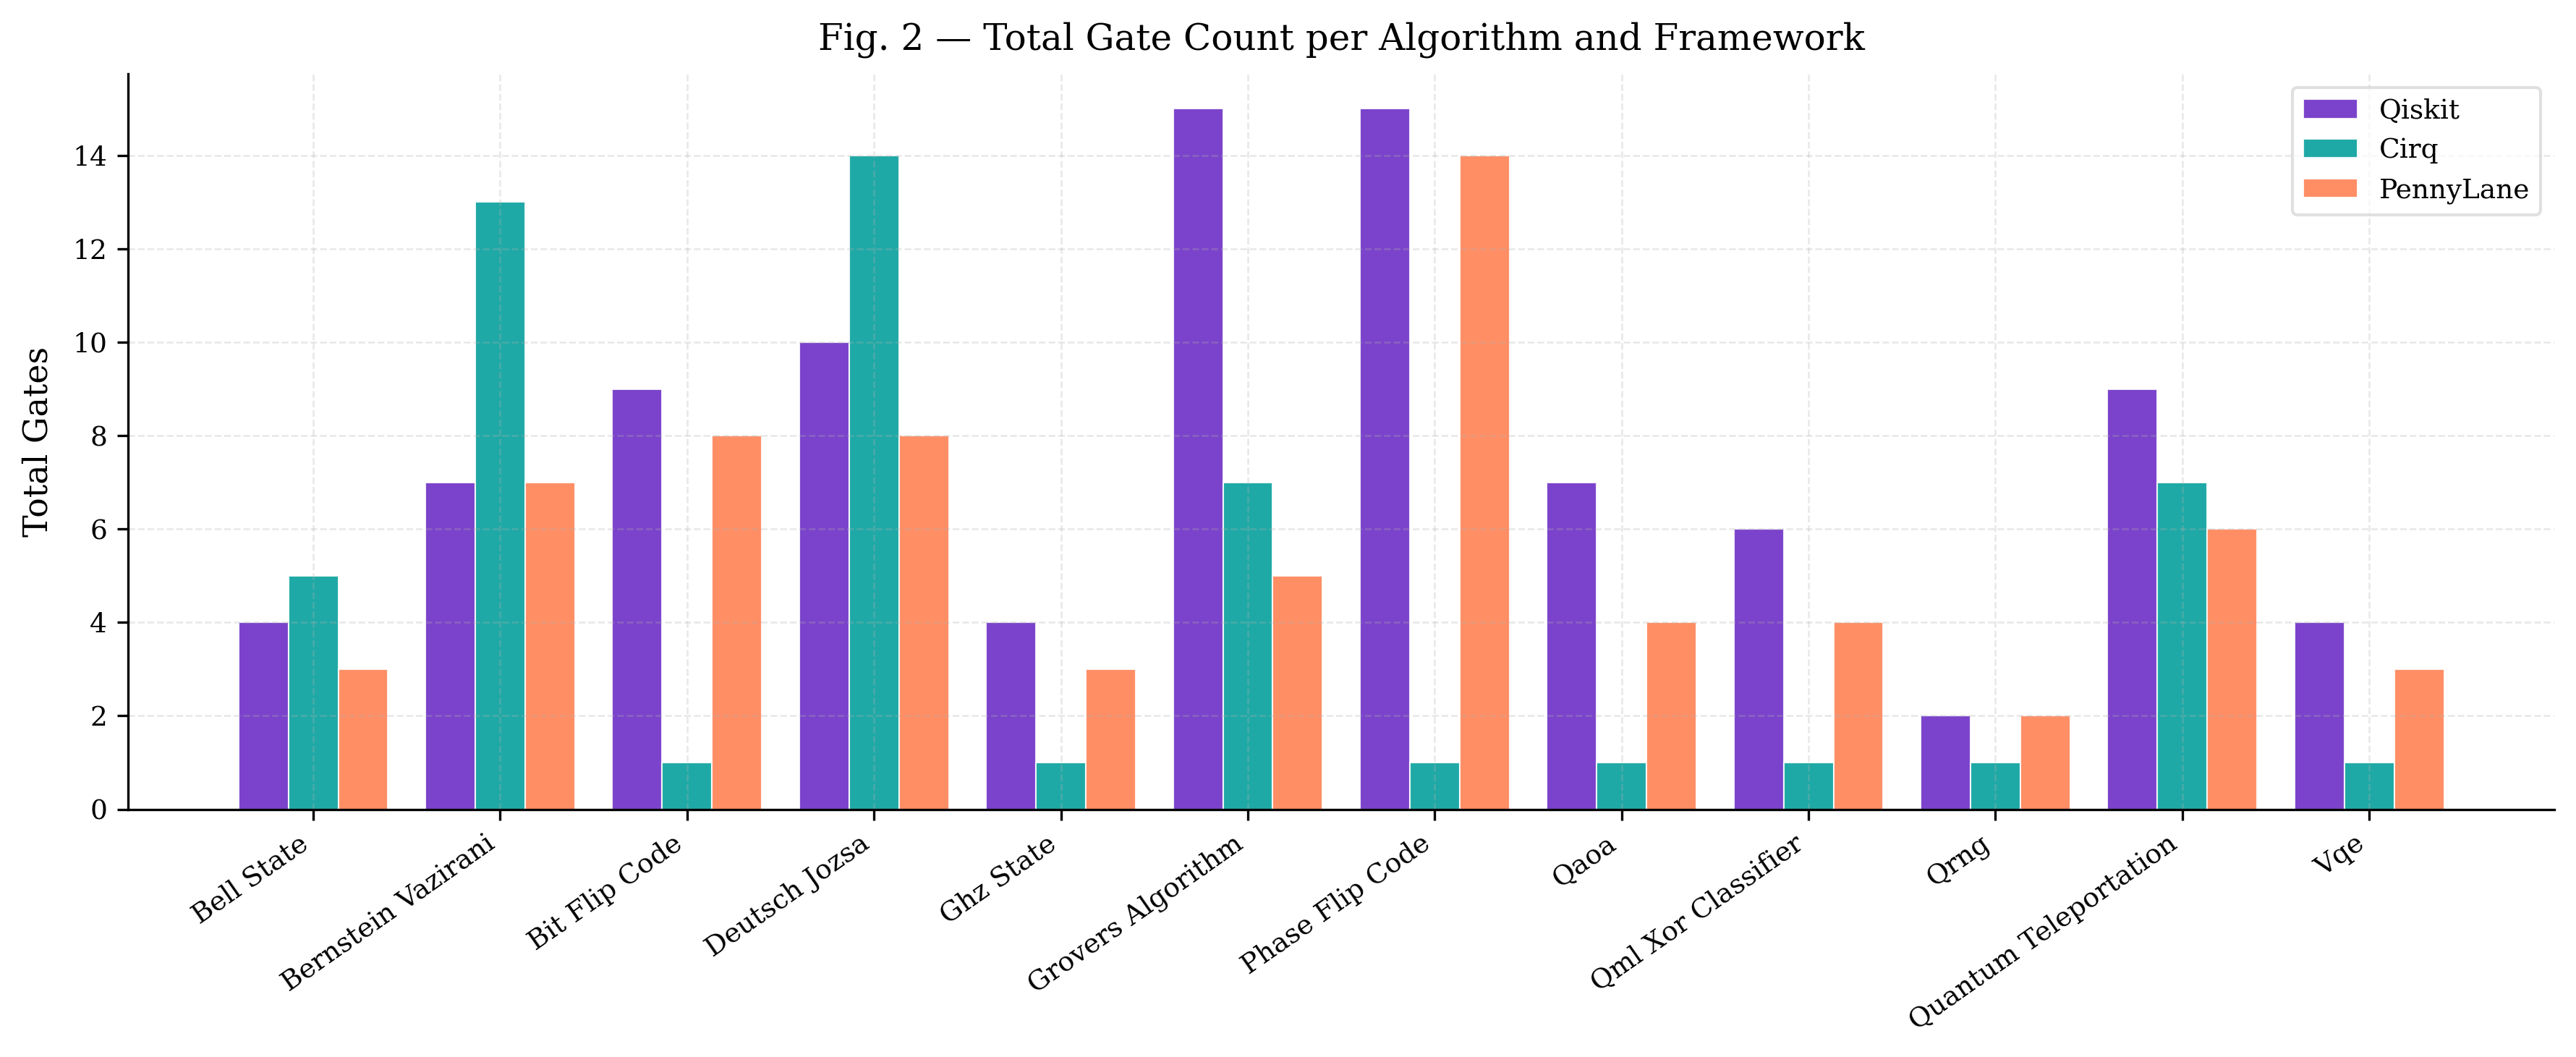

In [5]:
# ── Fig. 2: Gate count per algorithm per framework ───────────────────────────
apply_paper_style()
from benchmarks.scripts.figure_styles import plot_grouped_bar, save_figure

# Use fixed qubit count per algorithm for cross-framework comparison
df_fixed = df_struct[df_struct['n_qubits'] == df_struct.groupby('algorithm')['n_qubits'].transform('min')]

fig, ax = plt.subplots(figsize=(12, 5))
plot_grouped_bar(
    ax, df_fixed,
    x_col='algorithm', y_col='total_gates',
    title='Fig. 2 — Total Gate Count per Algorithm and Framework',
    ylabel='Total Gates',
)
plt.tight_layout()
save_figure(fig, 'fig02_gate_counts', 'structural')
plt.show()

[save_figure] Saved: fig03_circuit_depth.pdf / .png → benchmarks\results\structural/


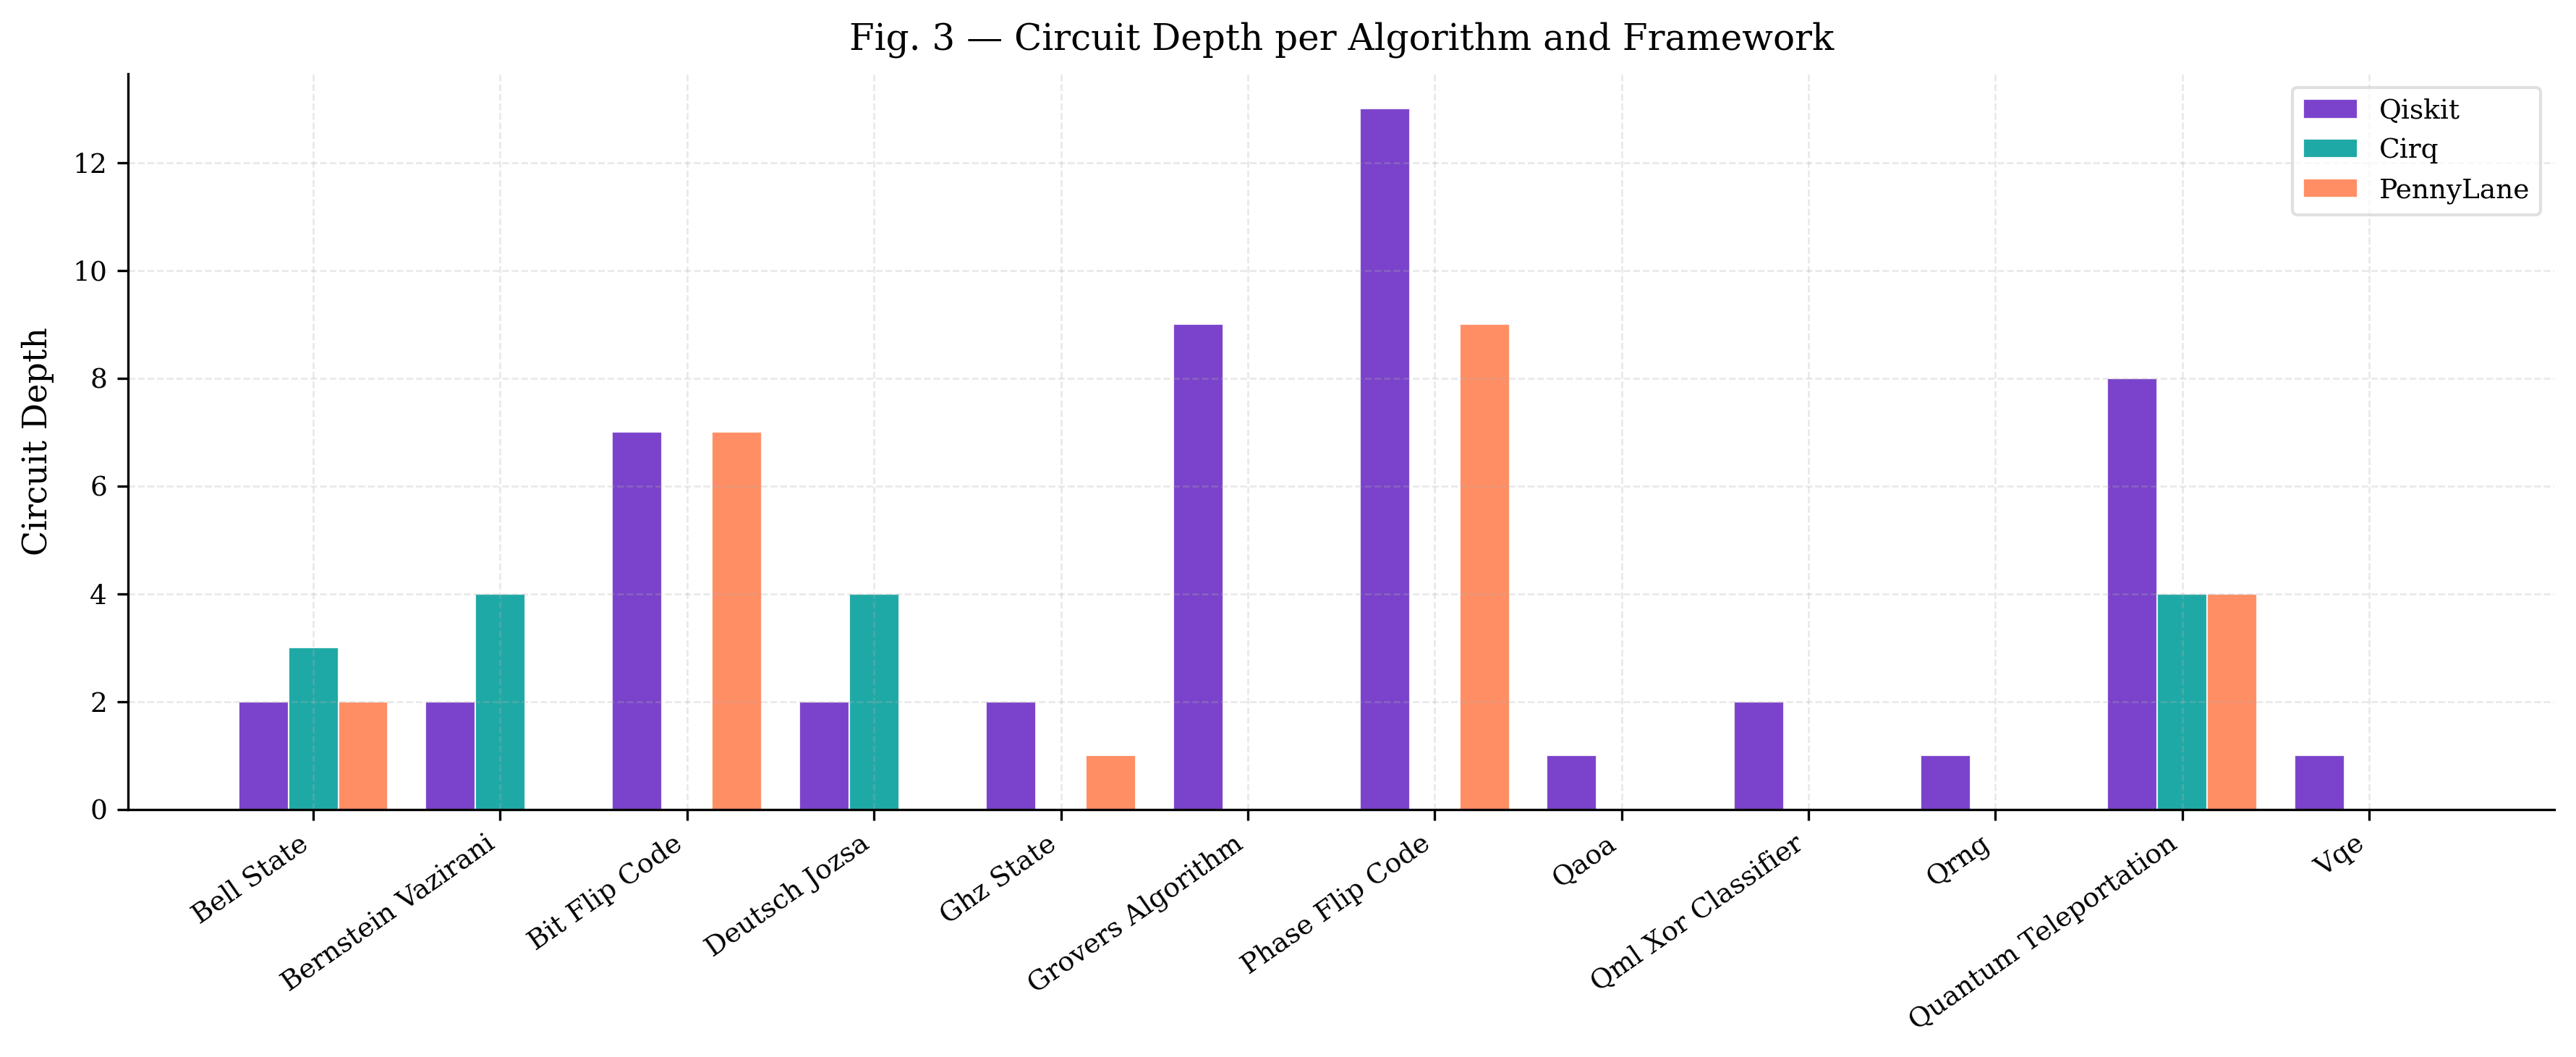

In [6]:
# ── Fig. 3: Circuit depth per algorithm per framework ────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
plot_grouped_bar(
    ax, df_fixed,
    x_col='algorithm', y_col='circuit_depth',
    title='Fig. 3 — Circuit Depth per Algorithm and Framework',
    ylabel='Circuit Depth',
)
plt.tight_layout()
save_figure(fig, 'fig03_circuit_depth', 'structural')
plt.show()

[save_figure] Saved: fig04_gate_composition.pdf / .png → benchmarks\results\structural/


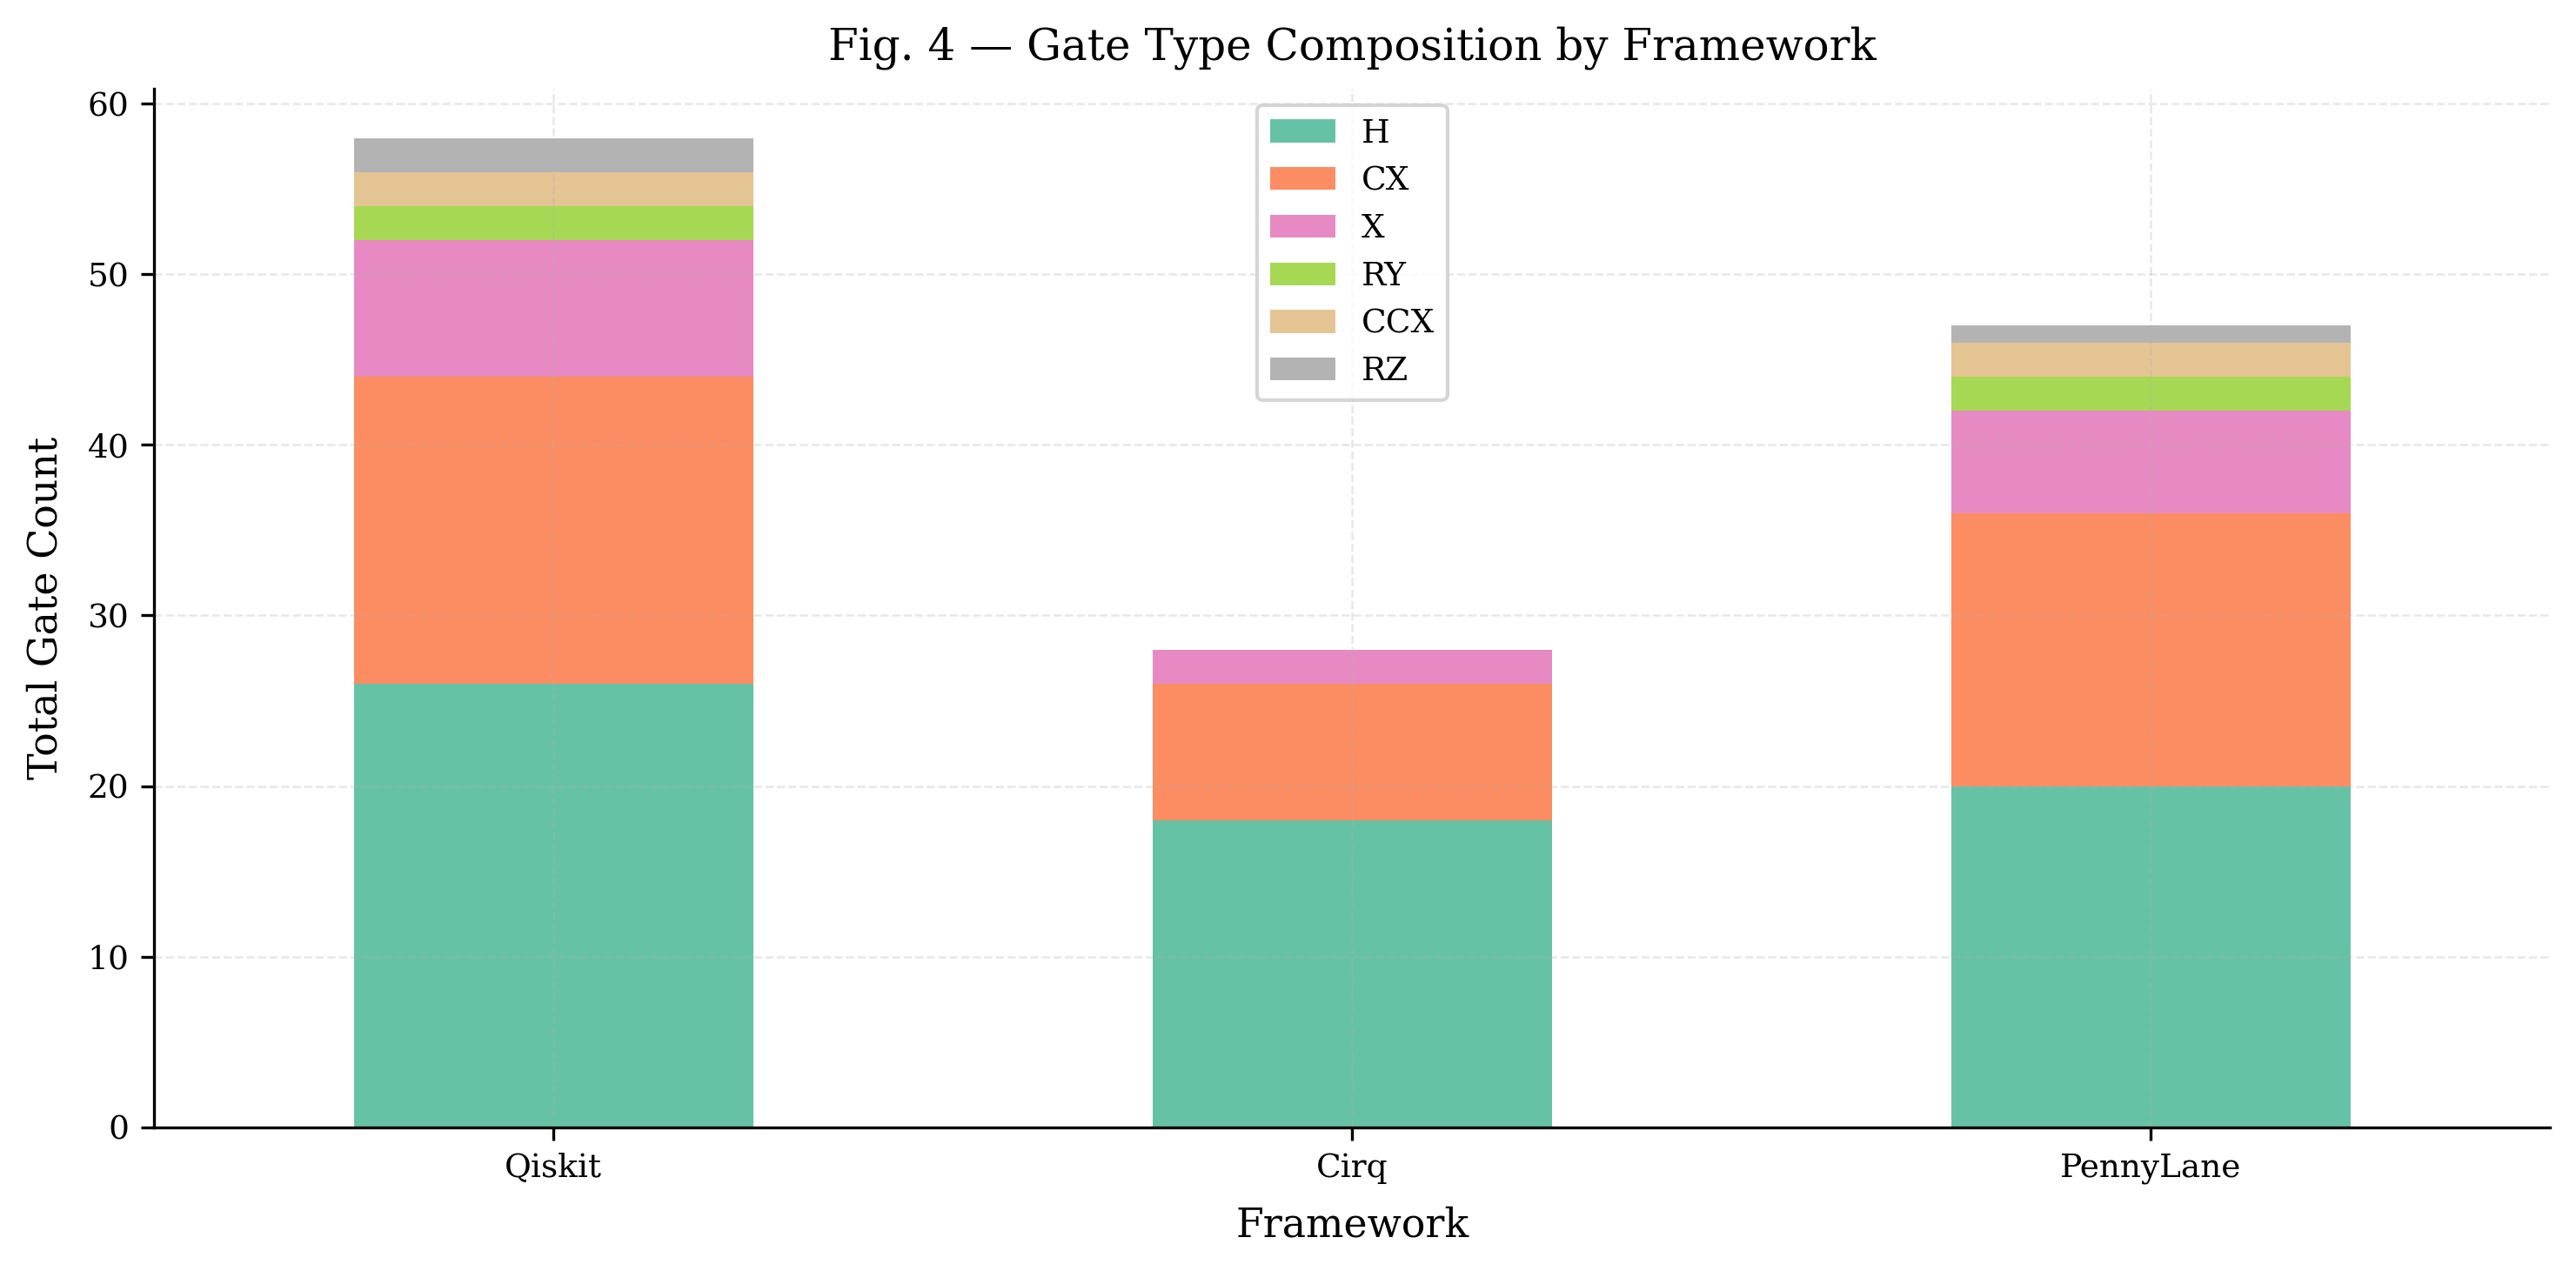

In [7]:
# ── Fig. 4: Gate composition (stacked bar) ───────────────────────────────────
import numpy as np

gate_cols = [c for c in df_struct.columns if c.startswith('gate_') and c != 'gate_MEASURE']
fw_totals = {}
for fw in ['qiskit', 'cirq', 'pennylane']:
    sub = df_fixed[df_fixed['framework'] == fw]
    fw_totals[FRAMEWORK_LABELS[fw]] = sub[gate_cols].sum()

df_gate_comp = pd.DataFrame(fw_totals).T
df_gate_comp.columns = [c.replace('gate_', '') for c in df_gate_comp.columns]

# Keep top 6 gate types by total count
top_gates = df_gate_comp.sum().nlargest(6).index
df_plot = df_gate_comp[top_gates]

apply_paper_style()
fig, ax = plt.subplots(figsize=(10, 5))
df_plot.plot(kind='bar', stacked=True, ax=ax,
             color=plt.cm.Set2(np.linspace(0, 1, len(top_gates))))
ax.set_title('Fig. 4 — Gate Type Composition by Framework')
ax.set_ylabel('Total Gate Count')
ax.set_xlabel('Framework')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
save_figure(fig, 'fig04_gate_composition', 'structural')
plt.show()

In [8]:
# ── QASM 3.0 modifier usage summary ────────────────────────────────────────
print('QASM 3.0 Modifier Usage (ctrl @, inv @, pow()):' )
mod_summary = df_struct.groupby('framework')[['ctrl_count', 'inv_count', 'pow_count']].sum()
print(mod_summary.to_string())

print('\nThis demonstrates QASM 3.0-specific features that distinguish QCanvas')
print('output from traditional QASM 2.0 transpilers.')

QASM 3.0 Modifier Usage (ctrl @, inv @, pow()):
           ctrl_count  inv_count  pow_count
framework                                  
cirq                0          0          0
pennylane           0          0          0
qiskit              0          0          0

This demonstrates QASM 3.0-specific features that distinguish QCanvas
output from traditional QASM 2.0 transpilers.
